# Experiment 01: Feature Engineering for Machine Learning
## Title: Handling Missing Values, Encoding Categorical Variables, and Scaling Numerical Attributes

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Required Libraries
Import essential Python libraries for data manipulation (`pandas`, `numpy`), data visualization (`matplotlib`, `seaborn`), and feature engineering (`scikit-learn`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Feature Engineering Modules
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Step 2: Load the Dataset (Auto MPG - Fuel Efficiency Dataset)
Load the classic Auto MPG dataset provided by Seaborn.

In [2]:
df = sns.load_dataset("mpg")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Step 3: Explore Dataset Structure & Summary Statistics
Inspect column data types, non-null counts, and statistical metrics of numerical features.

In [3]:
print("Column Data Types & Information:")
df.info()

print("\nSummary Statistics:")
df.describe().round(2)

Column Data Types & Information:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB

Summary Statistics:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.00,398.00,398.00,392.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,104.47,2970.42,15.57,76.01
std,7.82,1.70,104.27,38.49,846.84,2.76,3.70
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00
25%,17.50,4.00,104.25,75.00,2223.75,13.82,73.00
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00
75%,29.00,8.00,262.00,126.00,3608.00,17.18,79.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00


### Step 4: Check for Missing Values
Identify columns containing missing (NaN/null) entries and calculate total missing counts.

In [4]:
missing_values = df.isnull().sum()
print("\nColumns with Missing Values:")
print(missing_values[missing_values > 0])

print("\nTotal Missing Values in Dataset:", df.isnull().sum().sum())


Columns with Missing Values:
horsepower    6
dtype: int64

Total Missing Values in Dataset: 6


### Step 5: Handle Missing Values using SimpleImputer
Impute missing values in the `horsepower` column using `SimpleImputer` with a median strategy to prevent outlier distortion.

In [5]:
imputer = SimpleImputer(strategy='median')
df["horsepower"] = imputer.fit_transform(df[["horsepower"]])

print("\nMissing Values After Imputation:", df.isnull().sum().sum())
df[["horsepower"]].describe().round(2)


Missing Values After Imputation: 0


,horsepower
count,398.00
mean,104.30
std,38.22
min,46.00
25%,76.00
50%,93.50
75%,125.00
max,230.00


### Step 6: Feature Selection & Drop Irrelevant Columns
Remove unique identifier/high-cardinality features like `name` that do not contribute to numerical machine learning modeling.

In [6]:
df = df.drop(columns=["name"])

print("Remaining Columns:", df.columns.tolist())
df.head()

Remaining Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


### Step 7: Identify Categorical and Numerical Columns
Separate features into categorical and numerical types for targeted preprocessing.

In [7]:
categorical_cols = ["origin"]
numerical_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

print("\nUnique values in 'origin':", df["origin"].unique())

Categorical Columns: ['origin']
Numerical Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

Unique values in 'origin': <StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str


### Step 8: Encode Categorical Variables
Demonstrate categorical encoding using both **LabelEncoder** (for ordinal target variables) and **OneHotEncoder** / `pd.get_dummies()` (for nominal categorical features).

In [8]:
# 1. Label Encoding Demonstration
label_encoder = LabelEncoder()
origin_label_encoded = label_encoder.fit_transform(df["origin"])
print("Label Encoded 'origin' sample:", origin_label_encoded[:10])

# 2. One-Hot Encoding using pd.get_dummies() / OneHotEncoder
df_encoded = pd.get_dummies(df, columns=["origin"], prefix="origin")

print("\nColumns after One-Hot Encoding:", df_encoded.columns.tolist())
df_encoded.head()

Label Encoded 'origin' sample: [2 2 2 2 2 2 2 2 2 2]

Columns after One-Hot Encoding: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_europe', 'origin_japan', 'origin_usa']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,True


### Step 9: Scale Numerical Attributes (Standardization and Normalization)
Apply **StandardScaler** (Standardization: Mean=0, Std=1) and **MinMaxScaler** (Normalization: Range [0, 1]) to numerical attributes.

In [9]:
# 1. Standardization (StandardScaler)
scaler_std = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numerical_cols] = scaler_std.fit_transform(df_scaled[numerical_cols])

# 2. Normalization (MinMaxScaler)
scaler_minmax = MinMaxScaler()
df_normalized = df_encoded.copy()
df_normalized[numerical_cols] = scaler_minmax.fit_transform(df_normalized[numerical_cols])

print("Standardized Features Summary (Mean ~ 0, Std ~ 1):")
print(df_scaled[numerical_cols].describe().round(3))

print("\nNormalized Features Summary (Min = 0, Max = 1):")
df_normalized[numerical_cols].describe().round(3)

Standardized Features Summary (Mean ~ 0, Std ~ 1):
           mpg  cylinders  displacement  horsepower   weight  acceleration  \
count  398.000    398.000       398.000     398.000  398.000       398.000   
mean     0.000     -0.000        -0.000      -0.000   -0.000        -0.000   
std      1.001      1.001         1.001       1.001    1.001         1.001   
min     -1.859     -1.445        -1.204      -1.527   -1.605        -2.748   
25%     -0.770     -0.856        -0.856      -0.741   -0.883        -0.633   
50%     -0.066     -0.856        -0.431      -0.283   -0.197        -0.025   
75%      0.703      1.498         0.658       0.542    0.754         0.583   
max      2.957      1.498         2.512       3.293    2.565         3.352   

       model_year  
count     398.000  
mean       -0.000  
std         1.001  
min        -1.627  
25%        -0.815  
50%        -0.003  
75%         0.810  
max         1.622  

Normalized Features Summary (Min = 0, Max = 1):


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000,398.000,398.000,398.000,398.000,398.000,398.000
mean,0.386,0.491,0.324,0.317,0.385,0.450,0.501
std,0.208,0.340,0.269,0.208,0.240,0.164,0.308
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.226,0.200,0.094,0.163,0.173,0.347,0.250
50%,0.372,0.200,0.208,0.258,0.338,0.446,0.500
75%,0.532,1.000,0.501,0.429,0.566,0.546,0.750
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### Step 10: Visual Comparison of Features Before and After Scaling
Visualize feature distribution ranges using boxplots before scaling, after Standardization, and after Normalization.

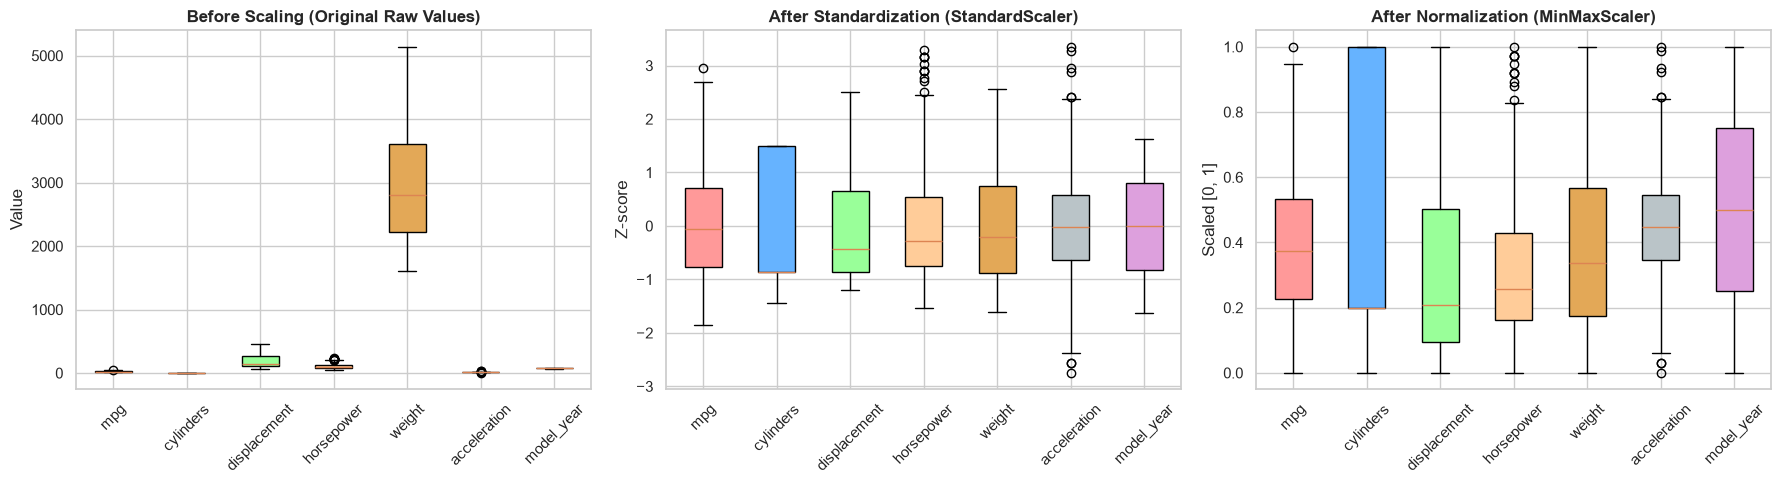

In [10]:
colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#E3A857', '#BAC4C8', '#DDA0DD']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Before Scaling
bp1 = axes[0].boxplot(df_encoded[numerical_cols].values, patch_artist=True)
axes[0].set_title("Before Scaling (Original Raw Values)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Value")
axes[0].set_xticklabels(numerical_cols, rotation=45)

# 2. After Standardization (StandardScaler)
bp2 = axes[1].boxplot(df_scaled[numerical_cols].values, patch_artist=True)
axes[1].set_title("After Standardization (StandardScaler)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Z-score")
axes[1].set_xticklabels(numerical_cols, rotation=45)

# 3. After Normalization (MinMaxScaler)
bp3 = axes[2].boxplot(df_normalized[numerical_cols].values, patch_artist=True)
axes[2].set_title("After Normalization (MinMaxScaler)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Scaled [0, 1]")
axes[2].set_xticklabels(numerical_cols, rotation=45)

# Apply custom colors
for bp in [bp1, bp2, bp3]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

plt.tight_layout()
plt.show()

### Step 11: End-to-End Automated Preprocessing Pipeline (`ColumnTransformer` & `Pipeline`)
Bundle missing value imputation, categorical one-hot encoding, and feature scaling into a single reusable scikit-learn `Pipeline`.

In [11]:
# Reload raw dataset for pipeline demonstration
raw_df = sns.load_dataset("mpg").drop(columns=["name"])

X = raw_df.drop(columns=["mpg"])
y = raw_df["mpg"]

num_features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
cat_features = ["origin"]

# Pipeline for numerical features: Median Imputation -> Standardization
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline for categorical features: Most Frequent Imputation -> OneHotEncoder
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, drop="first"))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Fit and transform raw data
X_processed = preprocessor.fit_transform(X)

print("Processed Features Array Shape:", X_processed.shape)
print("Pipeline Execution Completed Successfully!")

Processed Features Array Shape: (398, 8)
Pipeline Execution Completed Successfully!


### Step 12: Final Output & Summary Report
Display the final model-ready dataset and summary metrics.

In [12]:
print("="*70)
print("       Experiment 01 Summary Report               ")
print("="*70)
print("Original dataset shape :", df.shape)
print("Final dataset shape    :", df_scaled.shape)
print("Missing values handled : Yes (horsepower - median imputation)")
print("Categorical encoded    : Yes (origin - OneHotEncoder & LabelEncoder)")
print("Numerical scaled       : Yes (StandardScaler & MinMaxScaler)")
print("ML Pipeline created    : Yes (ColumnTransformer + Pipeline)")
print("="*70)

df_scaled.head()

       Experiment 01 Summary Report               
Original dataset shape : (398, 8)
Final dataset shape    : (398, 10)
Missing values handled : Yes (horsepower - median imputation)
Categorical encoded    : Yes (origin - OneHotEncoder & LabelEncoder)
Numerical scaled       : Yes (StandardScaler & MinMaxScaler)
ML Pipeline created    : Yes (ColumnTransformer + Pipeline)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,-0.706439,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,False,False,True
1,-1.090751,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,False,False,True
2,-0.706439,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,False,False,True
3,-0.962647,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,False,False,True
4,-0.834543,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,False,False,True
